# Cell 1 _ importing the libraries

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import confusion_matrix, classification_report
import time

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

2026-06-26 17:22:08.218669: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782494528.416746      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782494528.470753      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782494528.944017      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782494528.944059      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782494528.944063      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
base_path = '/kaggle/input'
print("Top level:", os.listdir(base_path))

Top level: ['datasets']


In [4]:
print("Inside datasets:")
print(os.listdir('/kaggle/input/datasets'))

Inside datasets:
['meowmeowmeowmeowmeow']


In [5]:
print("Inside meowmeowmeowmeowmeow:")
print(os.listdir('/kaggle/input/datasets/meowmeowmeowmeowmeow'))

Inside meowmeowmeowmeowmeow:
['gtsrb-german-traffic-sign']


In [6]:
print("Inside gtsrb-german-traffic-sign:")
print(os.listdir('/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'))

Inside gtsrb-german-traffic-sign:
['Meta', 'meta', 'Meta.csv', 'Train.csv', 'Test.csv', 'Test', 'test', 'Train', 'train']


In [7]:
train_path = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train'
classes = sorted(os.listdir(train_path), key=lambda x: int(x))
print(f"Number of classes: {len(classes)}")

# Check image count in first few classes
for cls in classes[:5]:
    count = len(os.listdir(os.path.join(train_path, cls)))
    print(f"  Class {cls}: {count} images")

Number of classes: 43
  Class 0: 210 images
  Class 1: 2220 images
  Class 2: 2250 images
  Class 3: 1410 images
  Class 4: 1980 images


In [8]:
# Checking whether is it neccessary to weighten classes or not
print("Image count per class(all 43):")
counts = {}
for cls in classes:
    count = len(os.listdir(os.path.join(train_path, cls)))
    counts[cls] = count
    print(f" Class {cls}: {count} images")

print(f"\nMin: {min(counts.values())}, Max: {max(counts.values())}")
print(f"Ratio (max/min): {max(counts.values()) / min(counts.values()):.1f}x")

Image count per class(all 43):
 Class 0: 210 images
 Class 1: 2220 images
 Class 2: 2250 images
 Class 3: 1410 images
 Class 4: 1980 images
 Class 5: 1860 images
 Class 6: 420 images
 Class 7: 1440 images
 Class 8: 1410 images
 Class 9: 1470 images
 Class 10: 2010 images
 Class 11: 1320 images
 Class 12: 2100 images
 Class 13: 2160 images
 Class 14: 780 images
 Class 15: 630 images
 Class 16: 420 images
 Class 17: 1110 images
 Class 18: 1200 images
 Class 19: 210 images
 Class 20: 360 images
 Class 21: 330 images
 Class 22: 390 images
 Class 23: 510 images
 Class 24: 270 images
 Class 25: 1500 images
 Class 26: 600 images
 Class 27: 240 images
 Class 28: 540 images
 Class 29: 270 images
 Class 30: 450 images
 Class 31: 780 images
 Class 32: 240 images
 Class 33: 689 images
 Class 34: 420 images
 Class 35: 1200 images
 Class 36: 390 images
 Class 37: 210 images
 Class 38: 2070 images
 Class 39: 300 images
 Class 40: 360 images
 Class 41: 240 images
 Class 42: 240 images

Min: 210, Max: 

# Cell 3 _ Setting up the train/validation split and data generators

In [9]:
IMG_SIZE = 96   # MobileNetV2`s smallest standard input size 
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=-0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    validation_split=0.15
)

train_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_gen = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Class indices:", train_gen.class_indices)
print("Train batches:", len(train_gen))
print("Val batches:", len(val_gen))

Found 33337 images belonging to 43 classes.
Found 5872 images belonging to 43 classes.
Class indices: {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, '35': 29, '36': 30, '37': 31, '38': 32, '39': 33, '4': 34, '40': 35, '41': 36, '42': 37, '5': 38, '6': 39, '7': 40, '8': 41, '9': 42}
Train batches: 521
Val batches: 92


In [10]:
# Building a safe mapping 
# Train_gen.class_indices maps folder_name (string) -> internal model index
# need to reverse : internal model index -> folder_name (which is the actual class number)

idx_to_classid = {v: k for k, v in train_gen.class_indices.items()}

print("Verifying the mapping (first five):")
for i in range(5):
    print(f" Model output index {i} -> actual GTSRB class ID {idx_to_classid[i]}")

Verifying the mapping (first five):
 Model output index 0 -> actual GTSRB class ID 0
 Model output index 1 -> actual GTSRB class ID 1
 Model output index 2 -> actual GTSRB class ID 10
 Model output index 3 -> actual GTSRB class ID 11
 Model output index 4 -> actual GTSRB class ID 12


# Cell 4 _ Calculating the class weights

In [11]:
from sklearn.utils.class_weight import compute_class_weight

class_labels = train_gen.classes

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)

class_weights = dict(enumerate(class_weights_array))

print("Class weights (showing a few extremes):")
sorted_weights = sorted(class_weights.items(), key=lambda x: x[1])
print("Lowest weight (most common classes):")
for idx, w in sorted_weights[:3]:
    print(f" GTSRB class {idx_to_classid[idx]}: weight {w:.3f}")

print("\nHighest weight (rarest classes):")
for idx, w in sorted_weights[-3:]:
    print(f" GTSRB class {idx_to_classid[idx]}: weight {w:.3f}")

Class weights (showing a few extremes):
Lowest weight (most common classes):
 GTSRB class 2: weight 0.405
 GTSRB class 1: weight 0.411
 GTSRB class 13: weight 0.422

Highest weight (rarest classes):
 GTSRB class 0: weight 4.331
 GTSRB class 19: weight 4.331
 GTSRB class 37: weight 4.331


# Cell 5 _ Building the model with MobileNetV2(frozen base)

In [12]:
base_model = MobileNetV2(
    weights = 'imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
predictions = Dense(43, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1782494570.989246      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782494570.995589      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,428,011 (9.26 MB)

 Trainable params: 169,771 (663.17 KB)

 Non-trainable params: 2,258,240 (8.61 MB)

# Cell 6 _ Phase 1 training (frozen base)

In [13]:
callbacks_phase1 = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=2, verbose=1)
]

history_frozen = model.fit(
    train_gen,
    epochs=12,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    class_weight=class_weights
)

baseline_loss, baseline_acc = model.evaluate(val_gen)
print(f"\nFrozen-base validation accuracy: {baseline_acc*100:.2f}%")

Epoch 1/12


I0000 00:00:1782494580.702300     143 service.cc:152] XLA service 0x7efb14010d70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782494580.702350     143 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782494580.702357     143 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782494581.890685     143 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-26 17:23:10.385402: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-26 17:23:10.532118: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1782494592.989647     143 device_co

214/521 ━━━━━━━━━━━━━━━━━━━━ 3:04 600ms/step - accuracy: 0.3077 - loss: 2.6736

2026-06-26 17:25:30.307620: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-26 17:25:30.445307: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 0.4414 - loss: 2.0144

2026-06-26 17:29:42.805296: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-26 17:29:42.949191: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-26 17:29:43.085527: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


521/521 ━━━━━━━━━━━━━━━━━━━━ 411s 754ms/step - accuracy: 0.5908 - loss: 1.3124 - val_accuracy: 0.5899 - val_loss: 1.3928 - learning_rate: 0.0010
Epoch 2/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 141s 271ms/step - accuracy: 0.7792 - loss: 0.5715 - val_accuracy: 0.6311 - val_loss: 1.2780 - learning_rate: 0.0010
Epoch 3/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 142s 273ms/step - accuracy: 0.8183 - loss: 0.4321 - val_accuracy: 0.6337 - val_loss: 1.2937 - learning_rate: 0.0010
Epoch 4/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.8335 - loss: 0.3783
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
521/521 ━━━━━━━━━━━━━━━━━━━━ 137s 263ms/step - accuracy: 0.8388 - loss: 0.3705 - val_accuracy: 0.6350 - val_loss: 1.3170 - learning_rate: 0.0010
Epoch 5/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 137s 262ms/step - accuracy: 0.8635 - loss: 0.3012 - val_accuracy: 0.6563 - val_loss: 1.2911 - learning_rate: 5.0000e-04
Epoch 6/12
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.8757 -

# Cell 7 _ Phase 2 : Unfreezing & FineTuning

In [14]:
# Unfreeze the last 30 layers of MobileNetV2
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# Recompile with a much lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_phase2 = [
    EarlyStopping(patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    ModelCheckpoint('/kaggle/working/best_traffic_model.h5', save_best_only=True)
]

history_finetuned = model.fit(
    train_gen, 
    epochs=26,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    class_weight=class_weights
)

Epoch 1/26
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.6633 - loss: 1.0314

521/521 ━━━━━━━━━━━━━━━━━━━━ 174s 301ms/step - accuracy: 0.6938 - loss: 0.8797 - val_accuracy: 0.6511 - val_loss: 1.3835 - learning_rate: 1.0000e-05
Epoch 2/26
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.7614 - loss: 0.5875

521/521 ━━━━━━━━━━━━━━━━━━━━ 141s 270ms/step - accuracy: 0.7654 - loss: 0.5608 - val_accuracy: 0.6659 - val_loss: 1.3057 - learning_rate: 1.0000e-05
Epoch 3/26
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.8049 - loss: 0.4425

521/521 ━━━━━━━━━━━━━━━━━━━━ 142s 273ms/step - accuracy: 0.8096 - loss: 0.4291 - val_accuracy: 0.6742 - val_loss: 1.2536 - learning_rate: 1.0000e-05
Epoch 4/26
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8250 - loss: 0.3747

521/521 ━━━━━━━━━━━━━━━━━━━━ 137s 263ms/step - accuracy: 0.8280 - loss: 0.3674 - val_accuracy: 0.6723 - val_loss: 1.2285 - learning_rate: 1.0000e-05
Epoch 5/26
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.8442 - loss: 0.3289

...

521/521 ━━━━━━━━━━━━━━━━━━━━ 147s 282ms/step - accuracy: 0.9529 - loss: 0.0954 - val_accuracy: 0.7539 - val_loss: 0.9607 - learning_rate: 5.0000e-06
Epoch 22/26
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9536 - loss: 0.0910

521/521 ━━━━━━━━━━━━━━━━━━━━ 142s 273ms/step - accuracy: 0.9540 - loss: 0.0911 - val_accuracy: 0.7532 - val_loss: 0.9594 - learning_rate: 5.0000e-06
Epoch 23/26
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9575 - loss: 0.0826

521/521 ━━━━━━━━━━━━━━━━━━━━ 139s 266ms/step - accuracy: 0.9555 - loss: 0.0848 - val_accuracy: 0.7590 - val_loss: 0.9367 - learning_rate: 5.0000e-06
Epoch 24/26
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9555 - loss: 0.0862

521/521 ━━━━━━━━━━━━━━━━━━━━ 142s 273ms/step - accuracy: 0.9559 - loss: 0.0846 - val_accuracy: 0.7495 - val_loss: 0.9367 - learning_rate: 5.0000e-06
Epoch 25/26
521/521 ━━━━━━━━━━━━━━━━━━━━ 142s 272ms/step - accuracy: 0.9568 - loss: 0.0822 - val_accuracy: 0.7590 - val_loss: 0.9588 - learning_rate: 5.0000e-06
Epoch 26/26
521/521 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9541 - loss: 0.0834

521/521 ━━━━━━━━━━━━━━━━━━━━ 142s 273ms/step - accuracy: 0.9567 - loss: 0.0817 - val_accuracy: 0.7578 - val_loss: 0.9288 - learning_rate: 5.0000e-06
Restoring model weights from the end of the best epoch: 26.


# Cell 8 _ Comparing frozen vs fine-tuned & saving the **accuracy/loss** plot

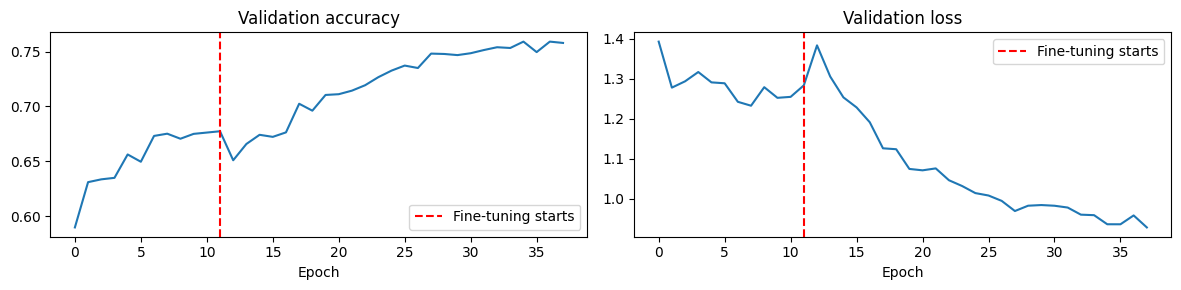

Frozen-base best val accuracy: 67.75%
Fine-tuned best val accuracy:  75.90%
Improvement from fine-tuning:  8.16 points


In [15]:
acc_frozen = history_frozen.history['val_accuracy']
acc_finetuned = history_finetuned.history['val_accuracy']
all_acc = acc_frozen + acc_finetuned

loss_frozen = history_frozen.history['val_loss']
loss_finetuned = history_finetuned.history['val_loss']
all_loss = loss_frozen + loss_finetuned

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

ax1.plot(all_acc)
ax1.axvline(x=len(acc_frozen)-1, color='red', linestyle='--', label='Fine-tuning starts')
ax1.set_title('Validation accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(all_loss)
ax2.axvline(x=len(loss_frozen)-1, color='red', linestyle='--', label='Fine-tuning starts')
ax2.set_title('Validation loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/accuracy_curve.png', dpi=150, bbox_inches='tight')
plt.show()

frozen_best = max(acc_frozen)
finetuned_best = max(acc_finetuned)
improvement = (finetuned_best - frozen_best) * 100

print(f"Frozen-base best val accuracy: {frozen_best*100:.2f}%")
print(f"Fine-tuned best val accuracy:  {finetuned_best*100:.2f}%")
print(f"Improvement from fine-tuning:  {improvement:.2f} points")

# Cell 9 _ Building the test set properly(the CSV-based approach)

In [16]:
import pandas as pd
test_csv_path = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Test.csv'
test_base_path = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign'

test_df = pd.read_csv(test_csv_path)
print(test_df.head())
print(f"\nTotal test images: {len(test_df)}")
print("Columns:", test_df.columns.tolist())

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId            Path
0     53      54       6       5      48      49       16  Test/00000.png
1     42      45       5       5      36      40        1  Test/00001.png
2     48      52       6       6      43      47       38  Test/00002.png
3     27      29       5       5      22      24       33  Test/00003.png
4     60      57       5       5      55      52       11  Test/00004.png

Total test images: 12630
Columns: ['Width', 'Height', 'Roi.X1', 'Roi.Y1', 'Roi.X2', 'Roi.Y2', 'ClassId', 'Path']


# Cell 10 _ LOading all the test images & labels into memory

In [17]:
from tensorflow.keras.preprocessing import image as keras_image

def load_test_data(df, base_path, img_size):
    images = []
    true_labels = []

    for idx, row in df.iterrows():
        img_path = os.path.join(base_path, row['Path'])
        img = keras_image.load_img(img_path, target_size=(img_size, img_size))
        img_array = keras_image.img_to_array(img)
        images.append(img_array)
        true_labels.append(row['ClassId'])

        if idx % 2000 == 0:
            print(f"Loaded {idx}/{len(df)} images ,,,")

    return np.array(images), np.array(true_labels)

X_test, y_test_classid = load_test_data(test_df, test_base_path, IMG_SIZE)

print(f"nTest images shape: {X_test.shape}")
print(f"Test labels shape: {y_test_classid.shape}")


Loaded 0/12630 images ,,,
Loaded 2000/12630 images ,,,
Loaded 4000/12630 images ,,,
Loaded 6000/12630 images ,,,
Loaded 8000/12630 images ,,,
Loaded 10000/12630 images ,,,
Loaded 12000/12630 images ,,,
nTest images shape: (12630, 96, 96, 3)
Test labels shape: (12630,)


# Cell 11 _ Preprocessing & converting classId labels to model`s internal index

In [18]:
# Apply the same preprocessing the model expects (matches preprocess_input from training)
X_test_processed = preprocess_input(X_test)

# Convert true ClassId labels into the model's internal index ordering
# Remember: model index -> idx_to_classid[index] = actual GTSRB class
# We need the OPPOSITE direction here: actual GTSRB class -> model index
classid_to_idx = {v: k for k, v in idx_to_classid.items()}

y_test_internal = np.array([classid_to_idx[str(cid)] for cid in y_test_classid])

print("Sample conversions:")
for i in range(5):
    print(f"  True ClassId {y_test_classid[i]} → model internal index {y_test_internal[i]}")

Sample conversions:
  True ClassId 16 → model internal index 8
  True ClassId 1 → model internal index 1
  True ClassId 38 → model internal index 32
  True ClassId 33 → model internal index 27
  True ClassId 11 → model internal index 3


# Cell 12 _ Evaluating on test set + confusion matrix

195/198 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7557 - loss: 0.9122

2026-06-26 18:58:35.802502: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-26 18:58:35.939287: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


198/198 ━━━━━━━━━━━━━━━━━━━━ 13s 66ms/step - accuracy: 0.7590 - loss: 0.9208

Test accuracy: 75.90%
198/198 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step


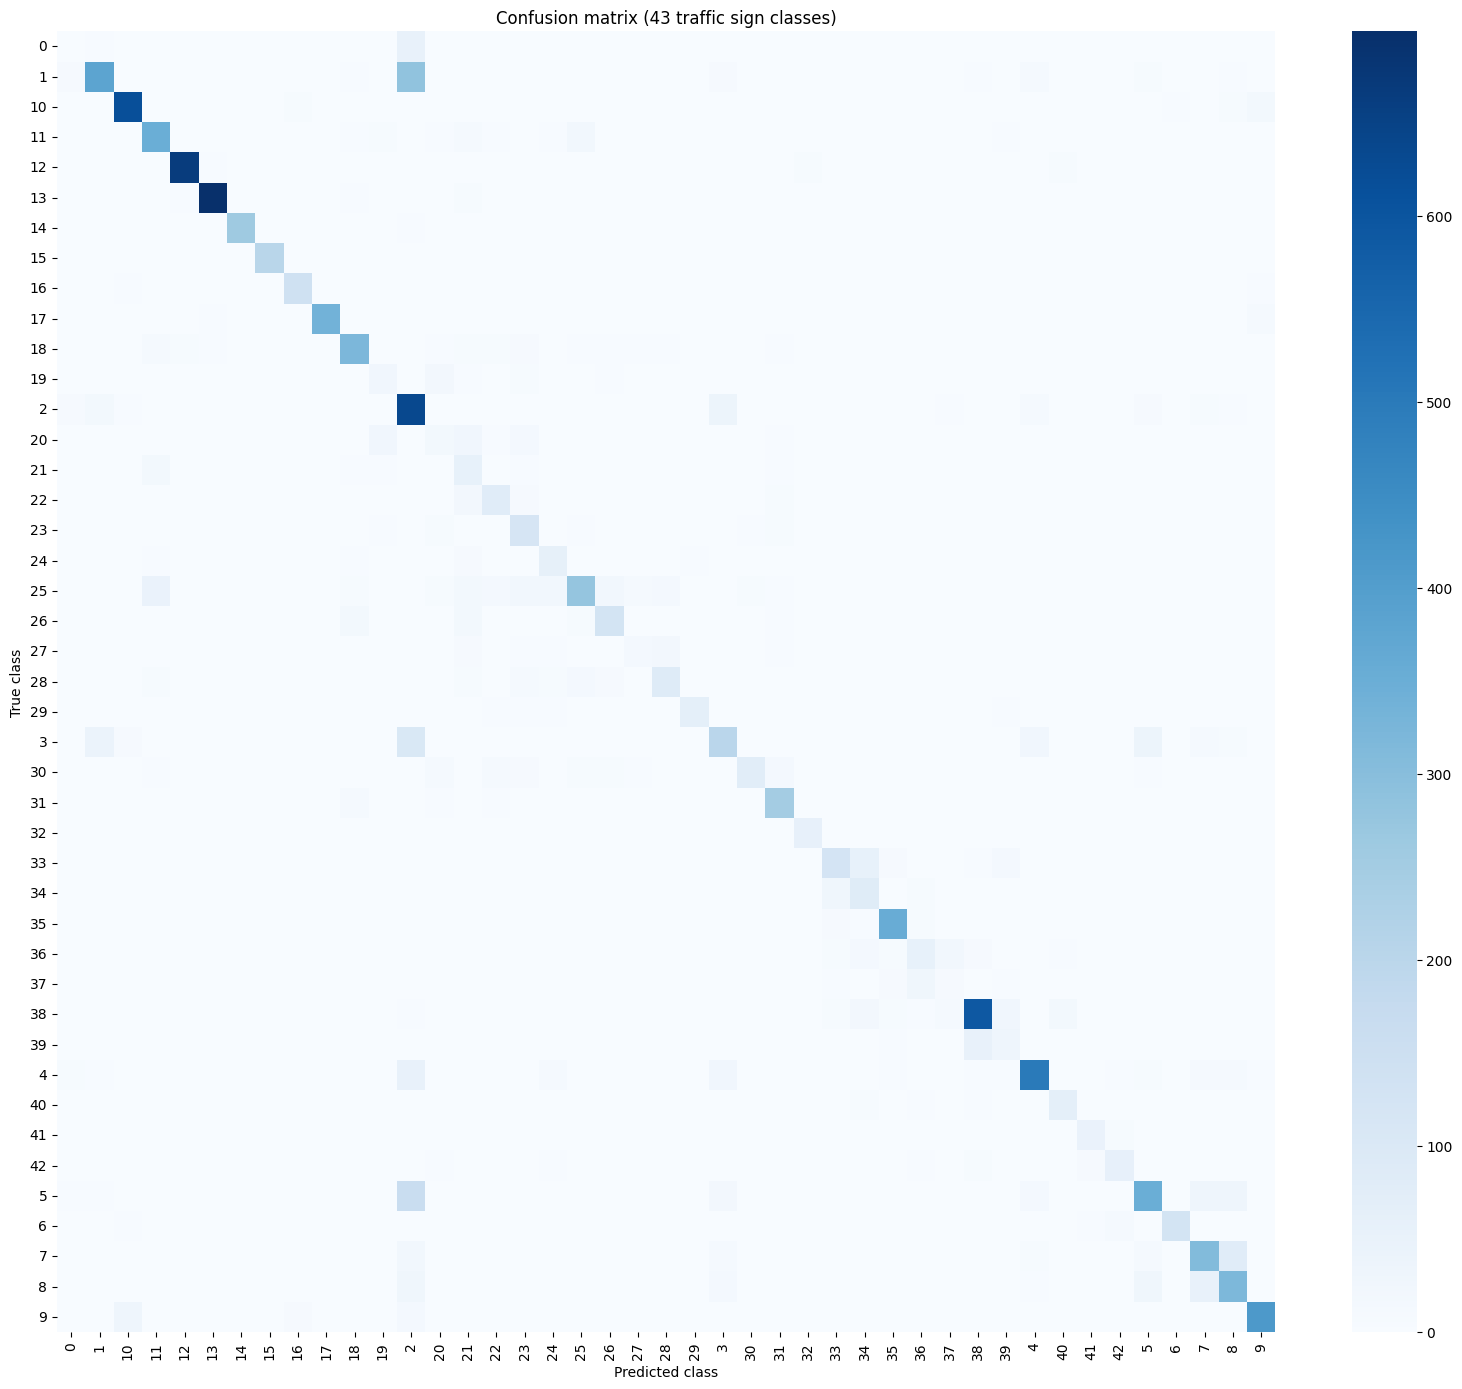


Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        60
           1       0.83      0.53      0.65       720
          10       0.91      0.93      0.92       660
          11       0.79      0.84      0.81       420
          12       0.97      0.96      0.97       690
          13       0.98      0.97      0.98       720
          14       0.98      0.97      0.98       270
          15       0.99      0.97      0.98       210
          16       0.88      0.95      0.92       150
          17       0.99      0.94      0.96       360
          18       0.84      0.83      0.83       390
          19       0.38      0.42      0.40        60
           2       0.46      0.85      0.60       750
          20       0.20      0.19      0.19        90
          21       0.28      0.61      0.38        90
          22       0.61      0.68      0.64       120
          23       0.54      0.79      0.64       150
   

In [19]:
from tensorflow.keras.utils import to_categorical

y_test_onehot = to_categorical(y_test_internal, num_classes=43)

test_loss, test_acc = model.evaluate(X_test_processed, y_test_onehot, batch_size=BATCH_SIZE)
print(f"\nTest accuracy: {test_acc*100:.2f}%")

y_pred = model.predict(X_test_processed, batch_size=BATCH_SIZE)
y_pred_internal = np.argmax(y_pred, axis=1)

# Build readable class names using the GTSRB class IDs for axis labels
class_names_sorted = [idx_to_classid[i] for i in range(43)]

cm = confusion_matrix(y_test_internal, y_pred_internal)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=class_names_sorted, yticklabels=class_names_sorted)
plt.title('Confusion matrix (43 traffic sign classes)')
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nClassification report:")
print(classification_report(y_test_internal, y_pred_internal,
                             target_names=class_names_sorted, zero_division=0))

In [20]:
meta_path = '/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Meta.csv'
meta_df = pd.read_csv(meta_path)
print(meta_df.head(10))

          Path  ClassId  ShapeId  ColorId SignId
0  Meta/27.png       27        0        0   1.32
1   Meta/0.png        0        1        0   3.29
2   Meta/1.png        1        1        0   3.29
3  Meta/10.png       10        1        0   3.27
4  Meta/11.png       11        0        0   1.22
5  Meta/12.png       12        2        2    2.3
6  Meta/13.png       13        4        0    2.1
7  Meta/14.png       14        3        0    2.2
8  Meta/15.png       15        1        0    3.1
9  Meta/16.png       16        1        0    3.3


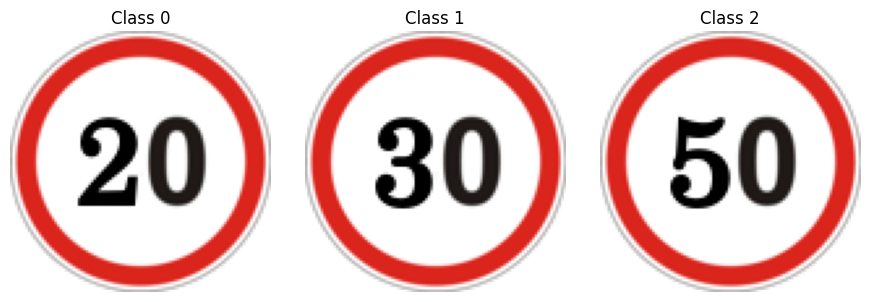

In [21]:
from PIL import Image as PILImage

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, cls in zip(axes, [0, 1, 2]):
    img = PILImage.open(f'/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Meta/{cls}.png')
    ax.imshow(img)
    ax.set_title(f'Class {cls}')
    ax.axis('off')
plt.tight_layout()
plt.show()

# Cell 13 _ saving the keras model

In [23]:
model.save('/kaggle/working/traffic_sign_model.h5')

import json
class_names_export = {str(i): idx_to_classid[i] for i in range(43)}
with open('/kaggle/working/class_names.json', 'w') as f:
    json.dump(class_names_export, f)

print("Keras model and class mapping saved")
print(f"Keras model file size: {os.path.getsize('/kaggle/working/traffic_sign_model.h5') / (1024*1024):.2f} MB")

Keras model and class mapping saved
Keras model file size: 22.76 MB


# Cell 14 _ Converting to TFLite

In [24]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

tflite_path = '/kaggle/working/traffic_sign_model.tflite'
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print("TFLite conversion complete!")
print(f"TFLite model file size: {os.path.getsize(tflite_path) / (1024*1024):.2f} MB")

INFO:tensorflow:Assets written to: /tmp/tmp9wbneud1/assets


INFO:tensorflow:Assets written to: /tmp/tmp9wbneud1/assets


Saved artifact at '/tmp/tmp9wbneud1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 43), dtype=tf.float32, name=None)
Captures:
  139620871044944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139618048738704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139618048741392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139618048741008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139618048737360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139618048741584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139618048740048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139618048742160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139618048741776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139618048739856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139618048738128

W0000 00:00:1782501059.027793      58 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1782501059.027846      58 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1782501059.191518      58 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled


# Cell 15 _ Measuring actual inference speed : **Keras vs TFLite**

In [25]:
# Set up the TFLite interpreter
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Use a small batch of test images for timing (single-image inference, like a real device would do)
n_samples = 100
sample_images = X_test_processed[:n_samples].astype(np.float32)

# --- Time the Keras model ---
start = time.time()
for i in range(n_samples):
    img = np.expand_dims(sample_images[i], axis=0)
    _ = model.predict(img, verbose=0)
keras_time = time.time() - start

# --- Time the TFLite model ---
start = time.time()
for i in range(n_samples):
    img = np.expand_dims(sample_images[i], axis=0)
    interpreter.set_tensor(input_details[0]['index'], img)
    interpreter.invoke()
    _ = interpreter.get_tensor(output_details[0]['index'])
tflite_time = time.time() - start

print(f"Keras model:  {keras_time:.3f}s total, {(keras_time/n_samples)*1000:.2f}ms per image")
print(f"TFLite model: {tflite_time:.3f}s total, {(tflite_time/n_samples)*1000:.2f}ms per image")
print(f"Speedup: {keras_time/tflite_time:.2f}x faster with TFLite")

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
2026-06-26 19:14:14.813042: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-26 19:14:14.963667: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-26 19:14:15.096605: E external/local_xla/xla/stream_executor/cuda/

Keras model:  19.630s total, 196.30ms per image
TFLite model: 0.196s total, 1.96ms per image
Speedup: 100.00x faster with TFLite


# Cell 16 _ Saving everything and building the Gradio demo

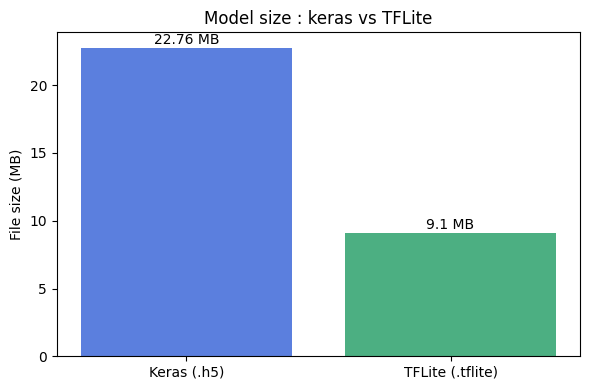

In [28]:
fig, ax = plt.subplots(figsize=(6, 4))
sizes = [22.76, 9.10]
labels = ['Keras (.h5)', 'TFLite (.tflite)']
ax.bar(labels, sizes, color=['#5B7FDE', '#4CAF82'])
ax.set_ylabel('File size (MB)')
ax.set_title('Model size : keras vs TFLite')
for i, v in enumerate(sizes):
    ax.text(i, v + 0.3, f'{v} MB', ha='center')
plt.tight_layout()
plt.savefig('/kaggle/working/model_size_comparison.png', dpi=150, bbox_inches='tight')
plt.show()